In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [35]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Nombre d'images train : {train_generator.samples}")
print(f"Nombre d'images validation : {val_generator.samples}")

print(train_generator.class_indices)
num_classes = train_generator.num_classes
print(train_generator.num_classes)


Found 5249 images belonging to 7 classes.
Found 1309 images belonging to 7 classes.
Nombre d'images train : 5249
Nombre d'images validation : 1309
{'peach_bacterial spot': 0, 'peach_healthy': 1, 'pepper-bell_bacterial spot': 2, 'pepper-bell_healthy': 3, 'potato_early blight': 4, 'potato_healthy': 5, 'potato_late blight': 6}
7


In [ ]:
def create_efficientnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=7):

    base_model = keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape  
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    
    return model, base_model

model_effnet, base_model = create_efficientnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes= num_classes)
model_effnet.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 4, 4, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_3  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               163968    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 7)                 903 

In [37]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

history_head = model_effnet.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/30
165/165 [==============================] - 66s 366ms/step - loss: 1.4038 - accuracy: 0.5771 - val_loss: 0.9864 - val_accuracy: 0.8021 - lr: 1.0000e-04
Epoch 2/30
165/165 [==============================] - 56s 337ms/step - loss: 0.9472 - accuracy: 0.7975 - val_loss: 0.8108 - val_accuracy: 0.8587 - lr: 1.0000e-04
Epoch 3/30
165/165 [==============================] - 55s 331ms/step - loss: 0.8235 - accuracy: 0.8543 - val_loss: 0.7382 - val_accuracy: 0.8969 - lr: 1.0000e-04
Epoch 4/30
165/165 [==============================] - 55s 334ms/step - loss: 0.7631 - accuracy: 0.8819 - val_loss: 0.6962 - val_accuracy: 0.9144 - lr: 1.0000e-04
Epoch 5/30
165/165 [==============================] - 55s 331ms/step - loss: 0.7360 - accuracy: 0.8977 - val_loss: 0.6699 - val_accuracy: 0.9282 - lr: 1.0000e-04
Epoch 6/30
165/165 [==============================] - 59s 358ms/step - loss: 0.7052 - accuracy: 0.9103 - val_loss: 0.6594 - val_accuracy: 0.9274 - lr: 1.0000e-04
Epoch 7/30
165/165 [========

In [ ]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 10 

for layer in base_model.layers:
    if not isinstance(layer, layers.BatchNormalization): 
        layer.trainable = True

model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss=loss_fn,
    metrics=['accuracy']
)


In [ ]:
history_finetune = model_effnet.fit(
    train_generator,
    epochs=20, 
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1,
    workers=4
)


Epoch 1/20
165/165 [==============================] - 176s 976ms/step - loss: 1.1981 - accuracy: 0.7039 - val_loss: 0.6924 - val_accuracy: 0.9244 - lr: 1.0000e-05
Epoch 2/20
165/165 [==============================] - 164s 991ms/step - loss: 0.9041 - accuracy: 0.8402 - val_loss: 0.7034 - val_accuracy: 0.9259 - lr: 1.0000e-05
Epoch 3/20
165/165 [==============================] - 160s 967ms/step - loss: 0.7812 - accuracy: 0.8849 - val_loss: 0.6715 - val_accuracy: 0.9366 - lr: 1.0000e-05
Epoch 4/20
165/165 [==============================] - 164s 991ms/step - loss: 0.7161 - accuracy: 0.9185 - val_loss: 0.6408 - val_accuracy: 0.9458 - lr: 1.0000e-05
Epoch 5/20
165/165 [==============================] - 158s 956ms/step - loss: 0.6784 - accuracy: 0.9324 - val_loss: 0.6197 - val_accuracy: 0.9603 - lr: 1.0000e-05
Epoch 6/20
165/165 [==============================] - 162s 980ms/step - loss: 0.6554 - accuracy: 0.9430 - val_loss: 0.6010 - val_accuracy: 0.9664 - lr: 1.0000e-05
Epoch 7/20
165/165 [==

In [41]:
# Concaténation des historiques pour le tracé 
loss = history_head.history['loss'] + history_finetune.history['loss']
val_loss = history_head.history['val_loss'] + history_finetune.history['val_loss']
accuracy = history_head.history['accuracy'] + history_finetune.history['accuracy']
val_accuracy = history_head.history['val_accuracy'] + history_finetune.history['val_accuracy']


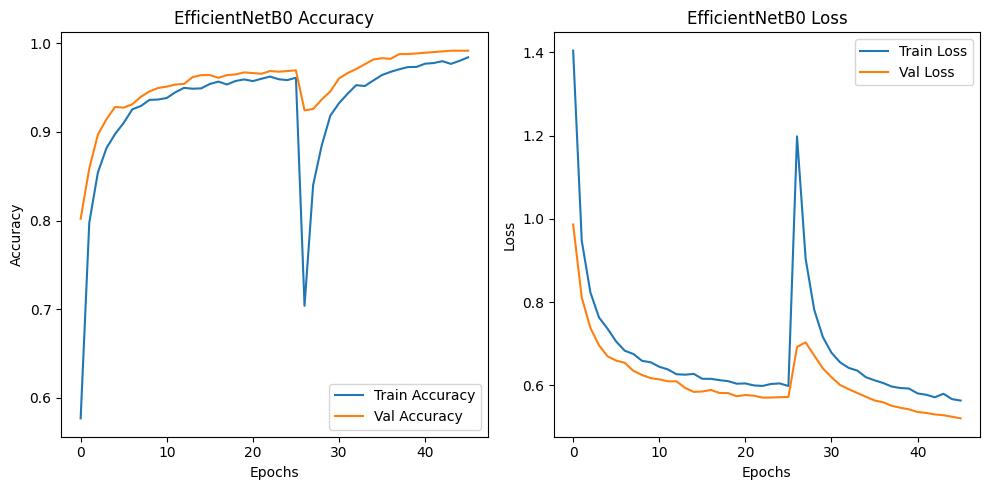

In [42]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetB0 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('EfficientNetB0 Loss')
plt.tight_layout()
plt.show()

In [46]:
model_effnet.save('models/efficientnet_transfer.h5')
print("Modèle EfficientNetB0 sauvegardé dans 'models/efficientnet_transfer.h5' !")

Modèle EfficientNetB0 sauvegardé dans 'models/efficientnet_transfer.h5' !
